In [65]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [66]:
df = pd.read_csv("Algerian_forest_fires_cleaned_dataset.csv")

In [67]:
df.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,1,6,2012,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,0
2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire,0
4,5,6,2012,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire,0


In [68]:
df.columns

Index(['day', 'month', 'year', 'Temperature', 'RH', 'Ws', 'Rain', 'FFMC',
       'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes', 'Region'],
      dtype='object')

In [69]:
df.drop(['day','month','year'],axis=1, inplace=True)
df.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire,0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire,0


In [70]:
df['Classes'] = np.where(df['Classes'].str.contains("not fire"), 0, 1)

In [71]:
df.tail()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
238,30,65,14,0.0,85.4,16.0,44.5,4.5,16.9,6.5,1,1
239,28,87,15,4.4,41.1,6.5,8.0,0.1,6.2,0.0,0,1
240,27,87,29,0.5,45.9,3.5,7.9,0.4,3.4,0.2,0,1
241,24,54,18,0.1,79.7,4.3,15.2,1.7,5.1,0.7,0,1
242,24,64,15,0.2,67.3,3.8,16.5,1.2,4.8,0.5,0,1


In [72]:
df['Classes'].value_counts()

Classes
1    137
0    106
Name: count, dtype: int64

In [73]:
# Independent and Dependent Features
x = df.drop('FWI', axis = 1)
y = df['FWI']

In [74]:
x.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,Classes,Region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0,0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0,0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0,0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0,0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0,0


In [75]:
y.head()

0    0.5
1    0.4
2    0.1
3    0.0
4    0.5
Name: FWI, dtype: float64

In [76]:
# Train test split
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(x,y,test_size = 0.25, random_state=42)

In [77]:
X_train.shape

(182, 11)

In [78]:
y_train.shape

(182,)

<Axes: >

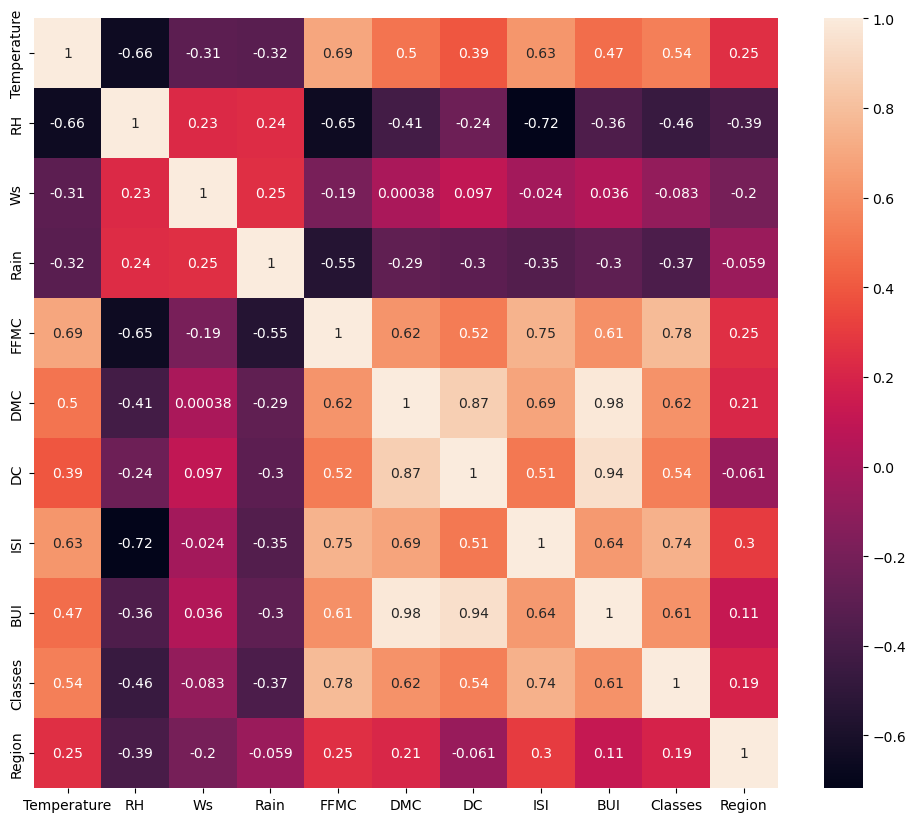

In [79]:
# Check for multicollinearity
plt.figure(figsize=(12,10))
corr = X_train.corr()
sns.heatmap(corr,annot=True)

In [80]:
def correlation(dataset, threshold):
    col_corr = set()
    corr_matrix = dataset.corr()
    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if abs(corr_matrix.iloc[i,j])>threshold:
                colname = corr_matrix.columns[i]
                col_corr.add(colname)
    return col_corr

In [81]:
corr_features = correlation(X_train, 0.70)

In [82]:
# Drop features when correlation is more than 0.85

X_train.drop(corr_features,axis = 1, inplace = True)
X_test.drop(corr_features,axis = 1, inplace = True)
X_train.shape, X_test.shape

((182, 7), (61, 7))

### Feature Scaling and Standardization

In [83]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

In [84]:
X_train_scaled.shape, X_test_scaled.shape

((182, 7), (61, 7))

### Box Plots to understand effect of standard scaler

Text(0.5, 1.0, 'X train after scaling')

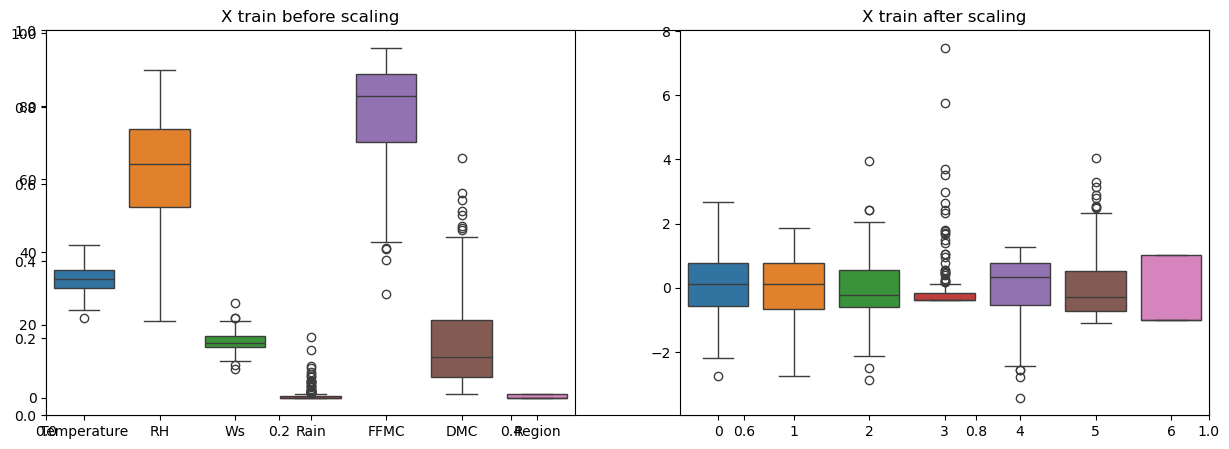

In [85]:
plt.subplots(figsize = (15,5))
plt.subplot(1,2,1)
sns.boxplot(data = X_train)
plt.title("X train before scaling")
plt.subplot(1,2,2)
sns.boxplot(data=X_train_scaled)
plt.title("X train after scaling")

# Model Training

In [98]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error
linreg = LinearRegression()
linreg.fit(X_train_scaled, y_train)
y_pred = linreg.predict(X_test)
mae = mean_absolute_error(y_test,y_pred)
print("Mean absolute error: ", mae)
score = r2_score(y_test, y_pred)
print("R2 Score: ", score)

Mean absolute error:  64.13074055785633
R2 Score:  -162.2844372373233


C:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(


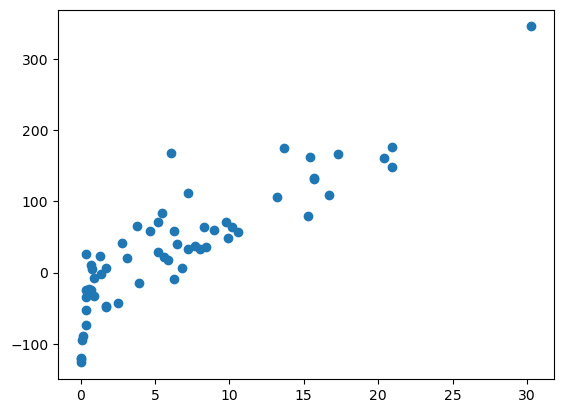

In [99]:
plt.scatter(y_test,y_pred)

Mean absolute error:  58.533541725711444
R2 score :  -135.12498670382865


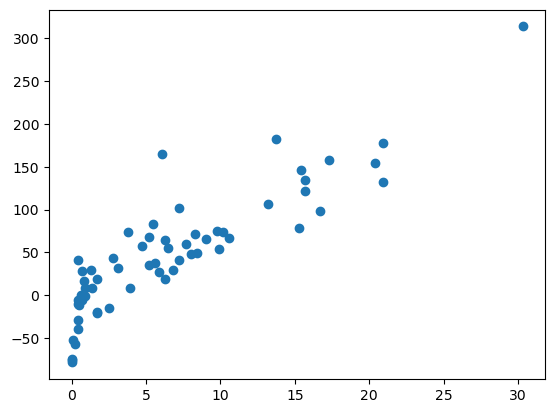

In [113]:
# Implementing the Lasso Regression
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_absolute_error, r2_score
import warnings
lasso = Lasso()
lasso.fit(X_train_scaled,y_train)
y_pred = lasso.predict(X_test.to_numpy())
mae = mean_absolute_error(y_test, y_pred)
score = r2_score(y_test,y_pred)
print("Mean absolute error: ",mae)
print("R2 score : ",score)
plt.scatter(y_test,y_pred)

Mean absolute error:  65.10952200604214
R2 score :  -165.8841336011628


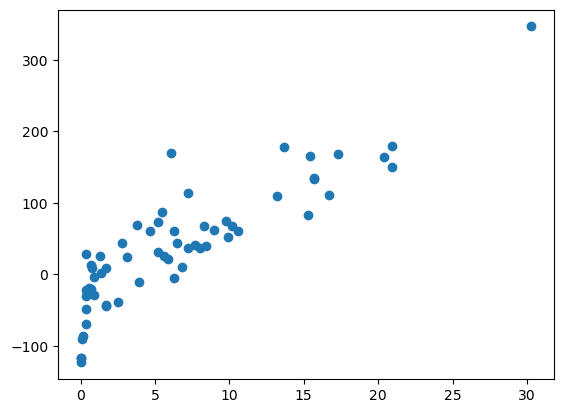

In [114]:
# Ridge Regression Model
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, r2_score
ridge = Ridge()
ridge.fit(X_train_scaled,y_train)
y_pred = ridge.predict(X_test.to_numpy())
mae = mean_absolute_error(y_test,y_pred)
score = r2_score(y_test,y_pred)
print("Mean absolute error: ", mae)
print("R2 score : ", score)
plt.scatter(y_test,y_pred)

Mean absolute error:  99.17407231348525
R2 Score :  -275.33773608030407


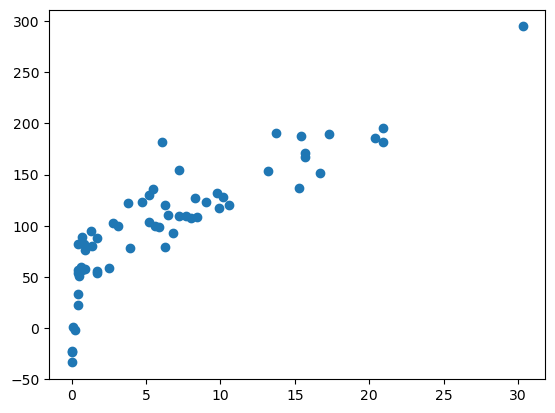

In [115]:
# Elastic Net Model
from sklearn.linear_model import ElasticNet
from sklearn.metrics import mean_absolute_error, r2_score
en = ElasticNet()
en.fit(X_train_scaled, y_train)
y_pred = en.predict(X_test.to_numpy())
mae = mean_absolute_error(y_test,y_pred)
score = r2_score(y_test,y_pred)
print("Mean absolute error: ", mae)
print("R2 Score : ", score)
plt.scatter(y_test,y_pred)

# LassoCV

In [116]:
from sklearn.linear_model import LassoCV
lassoCV = LassoCV(cv=5)
lassoCV.fit(X_train_scaled, y_train)
lassoCV.predict(X_test_scaled)

array([ 7.13021684,  6.33140705,  1.7682223 ,  9.20342089,  7.41027837,
        4.53927653,  0.91799026, 12.18155607,  1.69394122,  7.38733779,
        2.30639155, 17.91769425,  9.32828434, 17.72417768, 17.83985043,
        5.60355428,  4.76230349, -5.09427594,  5.05398769,  5.0381786 ,
        1.01090519, -1.27127779,  5.03985543,  0.28080173, 15.41823369,
        8.07738132,  5.94916841,  9.62613833, -5.50333671,  8.1719013 ,
        4.41748456,  1.42963212,  9.22928537, 15.65441383,  3.6483503 ,
        3.12804542,  0.55815257, 10.22647986, -2.86308261, -1.18770453,
        8.57491955,  3.80311303,  8.76528181, -4.78508886, 13.99602025,
        7.26732756,  8.17988342,  2.38604699, 12.87337565,  2.5153094 ,
       32.32106855,  9.04524643, 12.78031759, 19.1340253 , 10.83907419,
       19.95448155,  4.24436328,  8.86515909,  3.00753877, 16.35211795,
        6.31447839])

In [117]:
lassoCV.alpha_

np.float64(0.15566444891433542)

In [118]:
lassoCV.alphas_

array([6.73834239, 6.28420067, 5.86066658, 5.46567726, 5.09730891,
       4.75376735, 4.43337934, 4.13458441, 3.85592726, 3.59605067,
       3.35368889, 3.12766148, 2.91686756, 2.72028045, 2.53694266,
       2.36596121, 2.20650334, 2.0577924 , 1.91910408, 1.78976289,
       1.66913886, 1.55664449, 1.45173186, 1.35388999, 1.26264234,
       1.17754447, 1.09818191, 1.02416813, 0.95514262, 0.89076921,
       0.83073434, 0.77474563, 0.72253037, 0.67383424, 0.62842007,
       0.58606666, 0.54656773, 0.50973089, 0.47537673, 0.44333793,
       0.41345844, 0.38559273, 0.35960507, 0.33536889, 0.31276615,
       0.29168676, 0.27202805, 0.25369427, 0.23659612, 0.22065033,
       0.20577924, 0.19191041, 0.17897629, 0.16691389, 0.15566445,
       0.14517319, 0.135389  , 0.12626423, 0.11775445, 0.10981819,
       0.10241681, 0.09551426, 0.08907692, 0.08307343, 0.07747456,
       0.07225304, 0.06738342, 0.06284201, 0.05860667, 0.05465677,
       0.05097309, 0.04753767, 0.04433379, 0.04134584, 0.03855

In [119]:
lassoCV.mse_path_

array([[50.8129891 , 65.39074075, 52.50462315, 77.90299066, 41.59867037],
       [46.42020879, 61.07250415, 47.76817751, 77.90299066, 36.54285826],
       [42.55461285, 55.23199904, 43.60446554, 72.6661576 , 32.24150621],
       [39.15056645, 50.12622899, 39.94186658, 64.90148444, 28.58987932],
       [36.15077949, 45.66124608, 36.71788789, 58.20804626, 25.49732026],
       [33.50523339, 41.75522116, 33.87798925, 52.44227801, 22.88538634],
       [31.17024684, 38.33687326, 31.3745598 , 47.47958614, 20.6862311 ],
       [29.10766237, 35.34410314, 29.16602717, 43.21185916, 18.84119861],
       [27.28413797, 32.72280424, 27.21608202, 39.54530381, 17.29960259],
       [25.67053035, 30.39740594, 25.49300269, 36.39856409, 16.01766611],
       [24.24135772, 28.20714762, 23.96906725, 33.57860399, 14.72628033],
       [22.75570649, 26.19396431, 22.6200414 , 31.1093024 , 13.59363549],
       [21.22011718, 24.28124601, 21.1911882 , 28.97094537, 12.64636076],
       [19.63025272, 22.59692496, 19.4

(2.373520004018043, 0.7768361249289741)

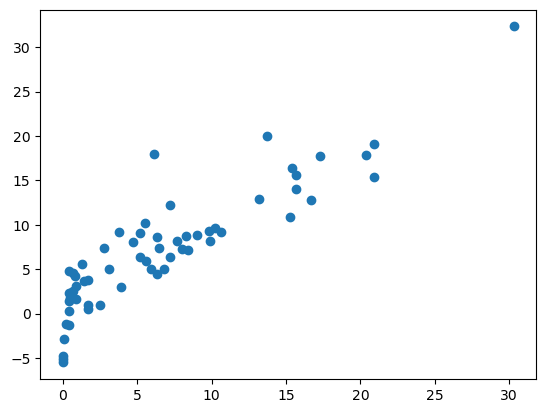

In [123]:
y_pred = lassoCV.predict(X_test_scaled)
plt.scatter(y_test,y_pred)
mae = mean_absolute_error(y_test,y_pred)
score = r2_score(y_test,y_pred)
mae,score

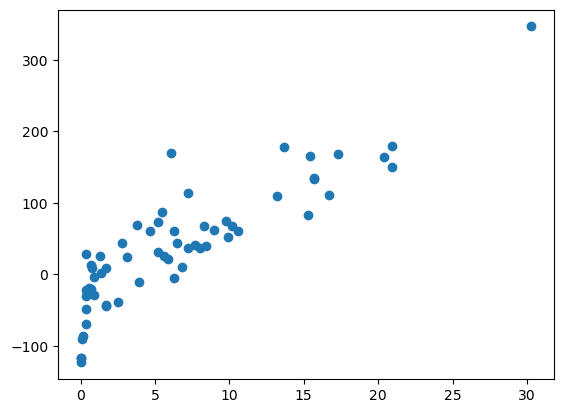

In [125]:
from sklearn.linear_model import RidgeCV
ridgeCV = RidgeCV(cv=5)
ridgeCV.fit(X_train_scaled,y_train)
y_pred = ridgeCV.predict(X_test.to_numpy())
mae = mean_absolute_error(y_test,y_pred)
score = r2_score(y_test,y_pred)
mae,score
plt.scatter(y_test,y_pred)

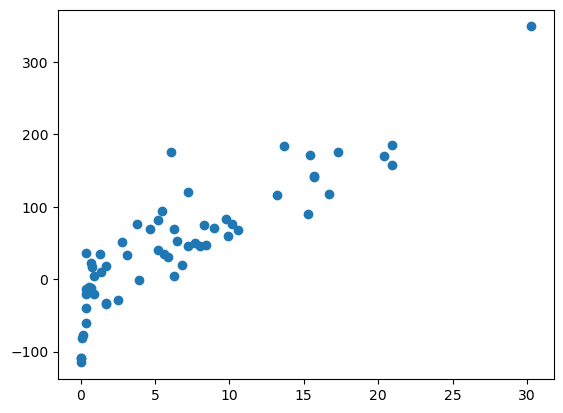

In [128]:
from sklearn.linear_model import ElasticNetCV
elastic = ElasticNetCV(cv=5)
elastic.fit(X_train_scaled,y_train)
y_pred = elastic.predict(X_test.to_numpy())
mae = mean_absolute_error(y_test,y_pred)
score = r2_score(y_test,y_pred)
mae,score
plt.scatter(y_test,y_pred)